In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex
import torch

from diffSPH.sampling import sampleRegularParticles, sampleOptimal
from diffSPH.operations import sph_operation, mod
from diffSPH.sampling import buildDomainDescription, sampleRegularParticles
from diffSPH.modules.eos import idealGasEOS
from diffSPH.schema import getSimulationScheme
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.reference.sod import plotSod
from diffSPH.operations import GradientMode, LaplacianMode, SupportScheme
from diffSPH.enums import *
from diffSPH.schemes.states.common import BasicState
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr, filterNeighborhoodByKind
from diffSPH.modules.density import computeDensity

from diffSPH.sdf import operatorDict, getSDF
from diffSPH.sphOperations.shared import scatter_sum
from matplotlib.colors import LogNorm

from waveEqn import WaveEquationState, waveEquation2
from typing import Union, Tuple
from diffSPH.neighborhood import SparseNeighborhood, PrecomputedNeighborhood
from diffSPH.operations import GradientMode, LaplacianMode
from diffSPH.kernels import SPHKernel
from diffSPH.enums import *
from diffSPH.operations import SPHOperation, Operation
from diffSPH.schemes.states.common import BasicState
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr, filterNeighborhoodByKind
from diffSPH.operations import ParticleSetWithQuantity, sph_op
from diffSPH.kernels import getSPHKernelv2
from diffSPH.plotting import visualizeParticles, updatePlot, plotDistribution
from diffSPH.operations import SPHOperation, Operation
from diffSPH.util import getPeriodicPositions
from diffSPH.integrationSchemes.util import integrateQ
from diffSPH.integration import getIntegrator
import copy
from waveEqn import WaveSystem, waveSystemFunction

In [38]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 64

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeDkDh': True
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

In [98]:
import h5py

from diffSPH.operations import ParticleSet

def sampleParticles(nx: int, scheme: str = 'regular'):
    device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
    dtype = torch.float32
    L = 2
    dim = 2

    kernel = KernelType.Wendland4
    targetNeighbors = n_h_to_nH(4, dim)

    domain = buildDomainDescription(L, dim, True, device, dtype)

    particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

    config = {
        'domain': domain,
        'kernel': kernel,
        'targetNeighbors': targetNeighbors,
        'neighborhood':{
            'verletScale': 1.0,
            'computeDkDh': True
        }
    }

    config['gradientMode'] = GradientMode.Difference
    config['laplacianMode'] = LaplacianMode.Brookshaw
    config['supportScheme'] = SupportScheme.Gather
    config['integrationScheme'] = IntegrationSchemeType.rungeKutta4
    
    if scheme == 'regular':
        particles = sampleRegularParticles(
            nx = nx,
            targetNeighbors=targetNeighbors,
            domain=domain,
        )
    elif scheme == 'regular_jittered':
        particles = sampleRegularParticles(
            nx = nx,
            targetNeighbors=targetNeighbors,
            domain=domain,
            jitter=0
        )
        dx = 2 * L / nx
        jitterAmount = dx * 0.25
        particles = particles._replace(
            positions = particles.positions + (torch.rand_like(particles.positions) - 0.5) * jitterAmount
        )
        
    elif scheme == 'random':
        particles = sampleRegularParticles(
            nx = nx,
            targetNeighbors=targetNeighbors,
            domain=domain,
            jitter=0.5
        )
        particles = particles._replace(
            positions = torch.rand_like(particles.positions) * L * 2 - L
        )
        
    elif scheme == 'optimal':
        particles = sampleOptimal(
            nx = nx,
            domain=domain,
            targetNeighbors=targetNeighbors,
            kernel=kernel,
            jitter = 0.5,
            shiftScheme='delta',
            shiftIters=128
        )
    elif scheme == 'glass':
        files = ['position_samples_1024.h5', 'position_samples_4096.h5', 'position_samples_16384.h5', 'position_samples_65536.h5']
        numParticles = nx ** dim
        selectedFile = None
        for file in files:
            if int(file.split('_')[-1].split('.')[0]) >= numParticles:
                selectedFile = file
                break
        if selectedFile is None:
            raise ValueError('No suitable glass file found for the given number of particles.')
        data = None
        with h5py.File(selectedFile, 'r') as f:
            data = f['positions']
            numSamples = data.shape[0]
            randomIndex = torch.randint(0, numSamples, (1,)).item()
            positions = torch.tensor(data[randomIndex], device=device, dtype=dtype)
            densities = f['densities'][randomIndex]
            supports = f['supports'][randomIndex]
            numNeighbors = f['numNeighbors'][randomIndex]
            counter = f['counter'][randomIndex]
            
            particles = ParticleSet(
                positions=positions,
                supports=torch.tensor(supports, device=device, dtype=dtype),
                masses=torch.ones_like(positions[:,0], device=device, dtype=dtype) * (L**dim / positions.shape[0]),
                densities=torch.tensor(densities, device=device, dtype=dtype),
            )
        return particles, torch.tensor(numNeighbors, device=device, dtype=dtype), torch.tensor(counter, device=device, dtype=dtype)

    particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
    neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
    particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
    particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

    neighs = neighbors.get('noghost')
    nnx = 63
    ddx = 2 / (nnx)
    hij = (particleState.supports[neighs[0].row] + particleState.supports[neighs[0].col]) / 2

    positions = neighs[1].x_ij / hij.view(-1,1)
    index = ((positions + 1) / ddx).to(torch.int64)
    linIdx = index[:,0] * nnx + index[:,1]
    counter = scatter_sum(torch.ones_like(linIdx), dim = 0, index = linIdx, dim_size = nnx**2).reshape(nnx,nnx).cpu()#.numpy()
        
    particles = particles._replace(densities = particleState.densities)    
    
    return particles, particleState.numNeighbors, counter

def visualize(
    particles: ParticleSet,
    numNeighbors: torch.Tensor,
    counter: torch.Tensor,
):    
    fig, axis = plt.subplots(1,3 , figsize=(14,4), squeeze=False)

    particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])

    visualizeParticles(fig, axis[0,0], particleState, config['domain'], particleState.densities,
        kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'viridis', markerSize = 0.25, gridVisualization = False, title = 'Particle Density')

    visualizeParticles(fig, axis[0,1], particleState, config['domain'], numNeighbors,
        kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = 0.25, gridVisualization = False, title = 'Number of Neighbors')

    sc = axis[0,2].imshow(counter.cpu().numpy().T, extent=(-1, 1, -1, 1), origin='lower', cmap='viridis', norm=LogNorm(vmin=1, vmax=counter.max().item()))
    fig.colorbar(sc, ax=axis[0,2], label='Number of Particles')
    axis[0,2].set_title('Relative Particle Distribution')
    fig.tight_layout()
    return fig, axis

In [101]:
os.makedirs('images', exist_ok=True)

0it [00:00, ?it/s]

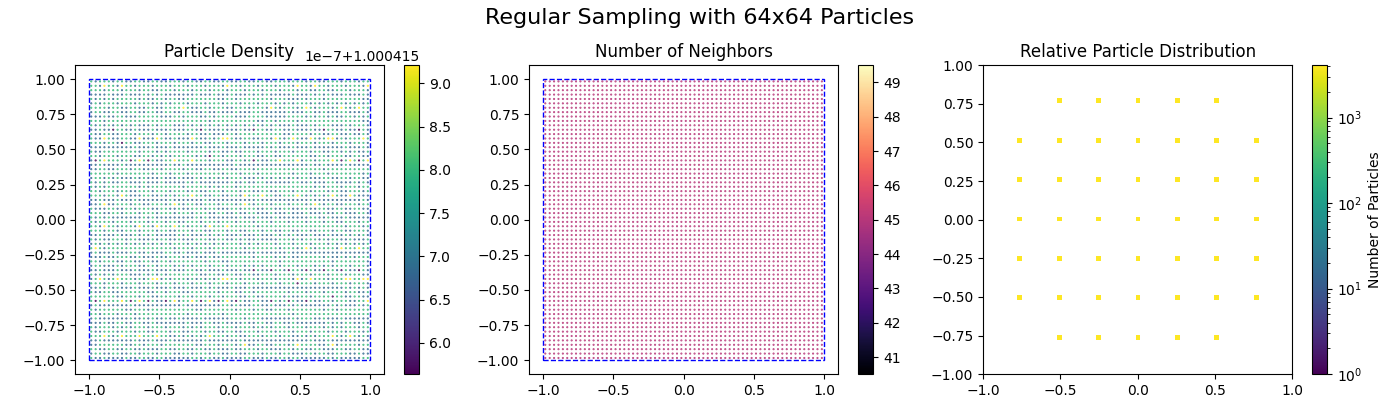

In [105]:
particles, numNeighbors, counter = sampleParticles(64, scheme='regular')
fig, axis = visualize(
    particles,
    numNeighbors,
    counter,
)
fig.suptitle('Regular Sampling with 64x64 Particles', fontsize=16)
fig.tight_layout()
fig.savefig('images/regular_64x64.png')

0it [00:00, ?it/s]

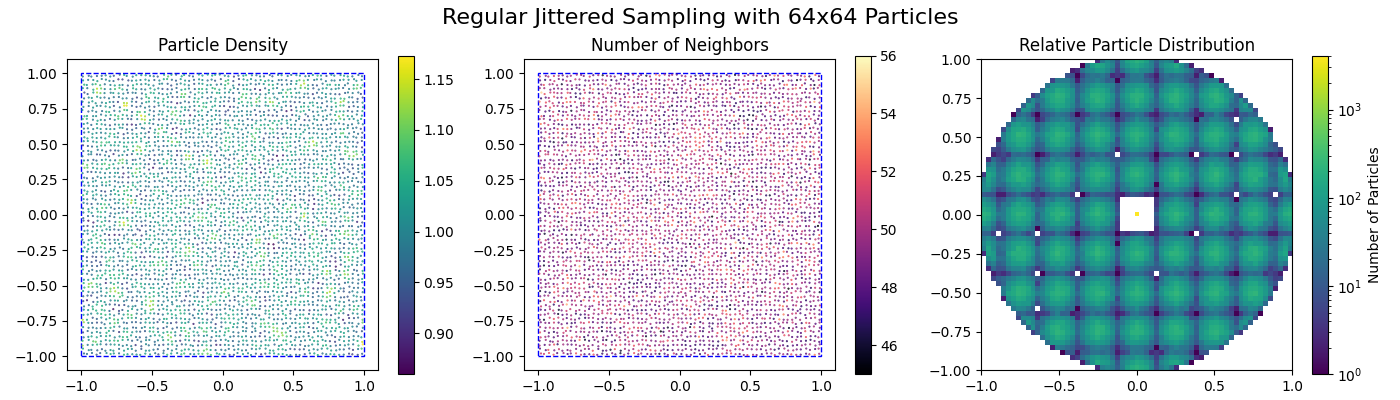

In [106]:
particles, numNeighbors, counter = sampleParticles(64, scheme='regular_jittered')
fig, axis = visualize(
    particles,
    numNeighbors,
    counter,
)
fig.suptitle('Regular Jittered Sampling with 64x64 Particles', fontsize=16)
fig.tight_layout()
fig.savefig('images/regular_jittered_64x64.png')

0it [00:00, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

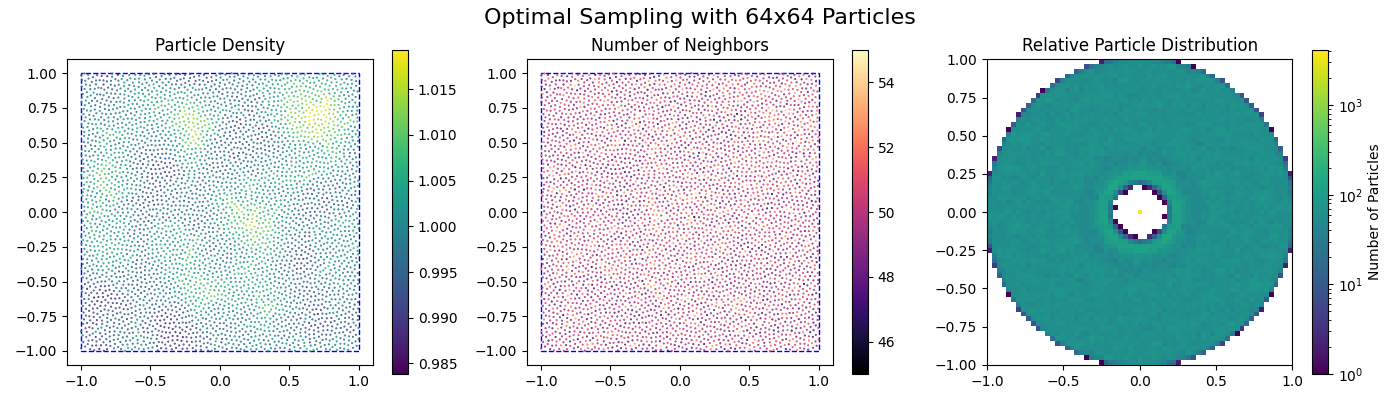

In [107]:
particles, numNeighbors, counter = sampleParticles(64, scheme='optimal')
fig, axis = visualize(
    particles,
    numNeighbors,
    counter,
)
fig.suptitle('Optimal Sampling with 64x64 Particles', fontsize=16)
fig.tight_layout()
fig.savefig('images/optimal_64x64.png')

0it [00:00, ?it/s]

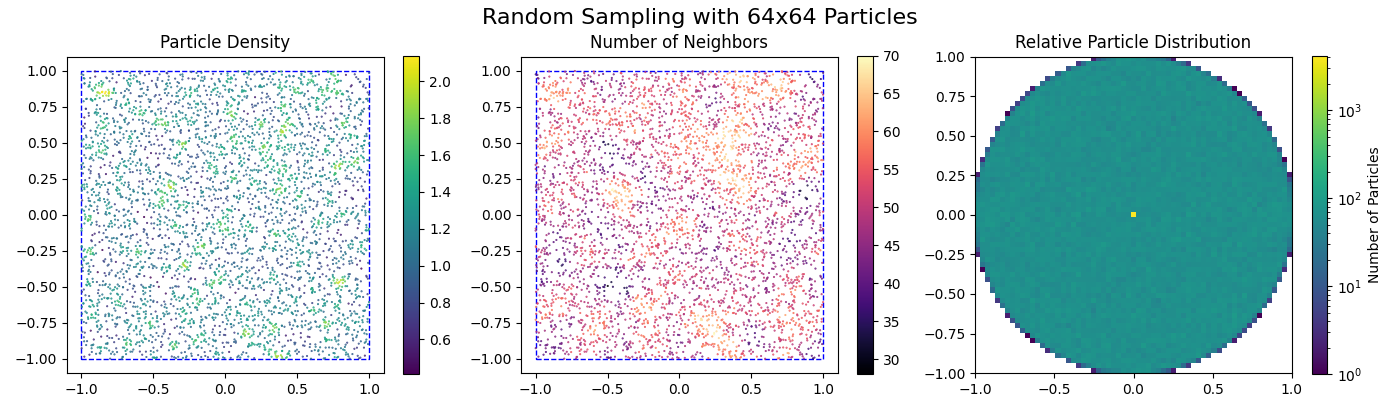

In [108]:
particles, numNeighbors, counter = sampleParticles(64, scheme='random')
fig, axis = visualize(
    particles,
    numNeighbors,
    counter,
)
fig.suptitle('Random Sampling with 64x64 Particles', fontsize=16)
fig.tight_layout()
fig.savefig('images/random_64x64.png')

0it [00:00, ?it/s]

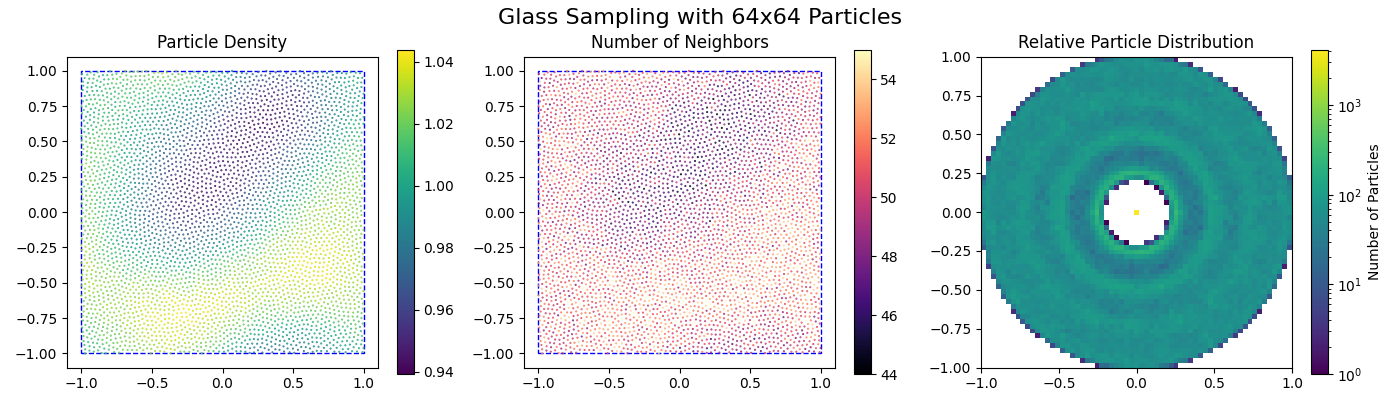

In [109]:
particles, numNeighbors, counter = sampleParticles(64, scheme='glass')
fig, axis = visualize(
    particles,
    numNeighbors,
    counter,
)
fig.suptitle('Glass Sampling with 64x64 Particles', fontsize=16)
fig.tight_layout()
fig.savefig('images/glass_64x64.png')

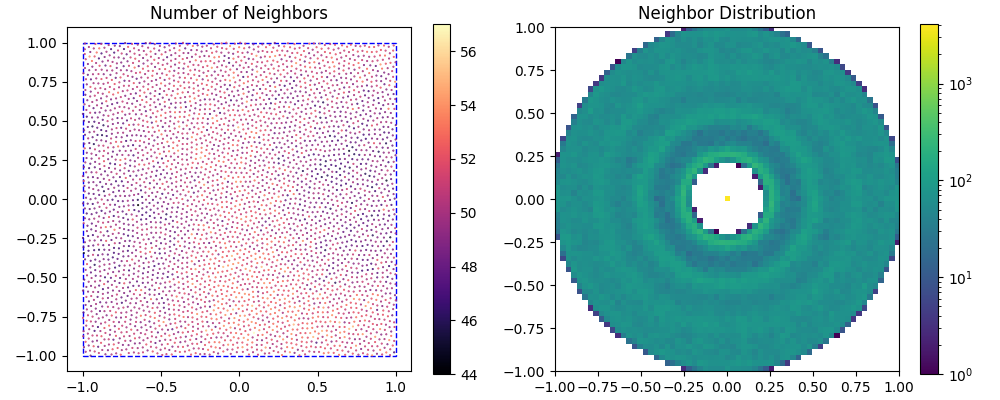

In [66]:
particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
visualizeParticles(fig, axis[0,0], particleState, config['domain'], particleState.numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = 0.25, gridVisualization = False, title = 'Number of Neighbors')
plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()